In [14]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# --- Electric: hourly kWh ---
elec1 = pd.read_csv("data/UsageData-01_01_2022-11_26_2024-clean.csv", parse_dates=["timestamp"])
elec2 = pd.read_csv("data/UsageData-11_27_2024-03_31_2026-clean.csv", parse_dates=["timestamp"])
elec2["timestamp"] = pd.to_datetime(elec2["timestamp"], utc=True).dt.tz_convert("America/New_York").dt.tz_localize(None)
elec = pd.concat([elec1, elec2], ignore_index=True).sort_values("timestamp").reset_index(drop=True)

# --- Meteorological: hourly observations ---
# Keeping: temp, rhum, prcp, wspd, pres, wdir — dropping sparse/derived cols (snwd, wpgt, tsun, cldc, coco, wchill)
WEATHER_COLS = ["temp", "rhum", "prcp", "wspd", "pres", "wdir"]
met1 = pd.read_csv("data/meteorological_observations_1_1_2022-11_24_2024.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met2 = pd.read_csv("data/meteorological_observations_11_27_2024-3_31_2026.csv", parse_dates=["time"], usecols=["time"] + WEATHER_COLS)
met = pd.concat([met1, met2], ignore_index=True).sort_values("time").reset_index(drop=True)

# --- Merge on hour ---
df = pd.merge(elec.rename(columns={"timestamp": "time"}), met, on="time", how="inner")
df = df.sort_values("time").reset_index(drop=True)

print(f"Merged range: {df['time'].min()} → {df['time'].max()}")
print(f"Rows: {len(df):,}  |  Columns: {list(df.columns)}")
df.head()

Merged range: 2022-01-01 00:00:00 → 2026-03-31 23:00:00
Rows: 37,168  |  Columns: ['time', 'kwh', 'temp', 'rhum', 'prcp', 'wdir', 'wspd', 'pres']


,time,kwh,temp,rhum,prcp,wdir,wspd,pres
0,2022-01-01 00:00:00,1.236,2.0,96,0.2,102.0,6.8,1016.0
1,2022-01-01 01:00:00,1.898,1.7,96,0.3,0.0,0.0,1015.6
2,2022-01-01 02:00:00,1.611,1.1,100,NaN,0.0,0.0,1015.3
3,2022-01-01 03:00:00,1.522,1.7,100,0.8,0.0,0.0,1015.0
4,2022-01-01 04:00:00,1.709,1.7,96,0.8,0.0,0.0,1015.0


In [15]:
# --- Time features (no year) ---
df["hour"]       = df["time"].dt.hour
df["dayofweek"]  = df["time"].dt.dayofweek   # 0=Mon … 6=Sun
df["month"]      = df["time"].dt.month

# Waking hour features
df['awake'] = ((df['hour'] >= 6) & (df['hour'] <= 23)).astype(int)

# Drop missing weather values
n_rows = len(df.index)
df = df.dropna(axis=0)
print(f'Dropped: {(n_rows - len(df.index))/n_rows:0.2%} of rows')
df.head()

Dropped: 5.86% of rows


,time,kwh,temp,rhum,prcp,wdir,wspd,pres,hour,dayofweek,month,awake
0,2022-01-01 00:00:00,1.236,2.0,96,0.2,102.0,6.8,1016.0,0,5,1,0
1,2022-01-01 01:00:00,1.898,1.7,96,0.3,0.0,0.0,1015.6,1,5,1,0
3,2022-01-01 03:00:00,1.522,1.7,100,0.8,0.0,0.0,1015.0,3,5,1,0
4,2022-01-01 04:00:00,1.709,1.7,96,0.8,0.0,0.0,1015.0,4,5,1,0
5,2022-01-01 05:00:00,1.857,2.2,100,0.3,0.0,0.0,1014.3,5,5,1,0


In [16]:
import numpy as np

def cyclical_encode(values, period):
    sin = np.sin(2 * np.pi * values / period)
    cos = np.cos(2 * np.pi * values / period)
    return sin, cos

df["hour_sin"], df["hour_cos"] = cyclical_encode(df["hour"], 24)
df["dayofweek_sin"],  df["dayofweek_cos"]  = cyclical_encode(df["dayofweek"], 7)
df["month_sin"],  df["month_cos"]  = cyclical_encode(df["month"], 12)
df["wdir_sin"], df["wdir_cos"] = cyclical_encode(df["wdir"], 360)


In [ ]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

WINDOW = 24  # look back 24 hours
RAW_FEATURES = ['temp', 'rhum', 'prcp', 'wspd', 'wdir_sin', 'wdir_cos', 'kwh']

data = df[RAW_FEATURES].values  # shape: (n_hours, 7)

# Scale first
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)

# Build sliding windows
X_windows = []
y_targets = []
for i in range(WINDOW, len(data_scaled)):
    X_windows.append(data_scaled[i-WINDOW:i])  # past 24 hours: (24, 7)
    y_targets.append(data_scaled[i, -1])         # next hour's kwh (scaled)

X_windows = np.array(X_windows)  # (n_samples, 24, 7)
y_targets = np.array(y_targets)  # (n_samples,)

# Temporal split
split_idx = int(len(X_windows) * 0.75)
X_train = X_windows[:split_idx]
X_test = X_windows[split_idx:]
y_train = y_targets[:split_idx]
y_test = y_targets[split_idx:]

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Convert to tensors — CNN expects (batch, channels, length)
X_train_t = torch.tensor(X_train, dtype=torch.float32).permute(0, 2, 1)  # (n, 7, 24)
X_test_t = torch.tensor(X_test, dtype=torch.float32).permute(0, 2, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

# Model
class CNN1D(nn.Module):
    def __init__(self, n_channels, window_size):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_channels, 32, kernel_size=3, padding=1),  # 7 input channels → 32 filters
            nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),          # 32 → 64 filters
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)                                # collapse time dim → (batch, 64, 1)
        )
        self.fc = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    
    def forward(self, x):
        x = self.conv(x)          # (batch, 64, 1)
        x = x.squeeze(-1)         # (batch, 64)
        return self.fc(x)         # (batch, 1)


In [19]:
model = CNN1D(n_channels=7, window_size=WINDOW)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5)
criterion = nn.MSELoss()

train_losses = []
test_losses = []

n_epochs = 100
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0
    for Xb, yb in train_loader:
        pred = model(Xb)
        loss = criterion(pred, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_loader))
    
    model.eval()
    with torch.no_grad():
        test_loss = criterion(model(X_test_t), y_test_t).item()
    test_losses.append(test_loss)
    scheduler.step(test_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | Test MSE: {test_loss:.4f} | LR: {optimizer.param_groups[0]['lr']:.6f}")


Epoch  10 | Test MSE: 0.3835 | LR: 0.001000
Epoch  20 | Test MSE: 0.3787 | LR: 0.001000
Epoch  30 | Test MSE: 0.3882 | LR: 0.001000
Epoch  40 | Test MSE: 0.3865 | LR: 0.001000
Epoch  50 | Test MSE: 0.3976 | LR: 0.000500
Epoch  60 | Test MSE: 0.4032 | LR: 0.000500
Epoch  70 | Test MSE: 0.4108 | LR: 0.000250
Epoch  80 | Test MSE: 0.4117 | LR: 0.000250
Epoch  90 | Test MSE: 0.4153 | LR: 0.000125
Epoch 100 | Test MSE: 0.4263 | LR: 0.000125


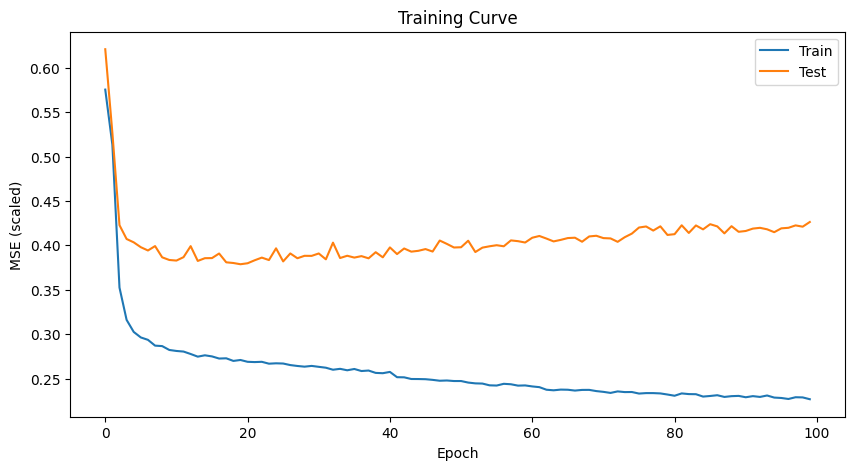

In [20]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train')
plt.plot(test_losses, label='Test')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.title('Training Curve')
plt.show()

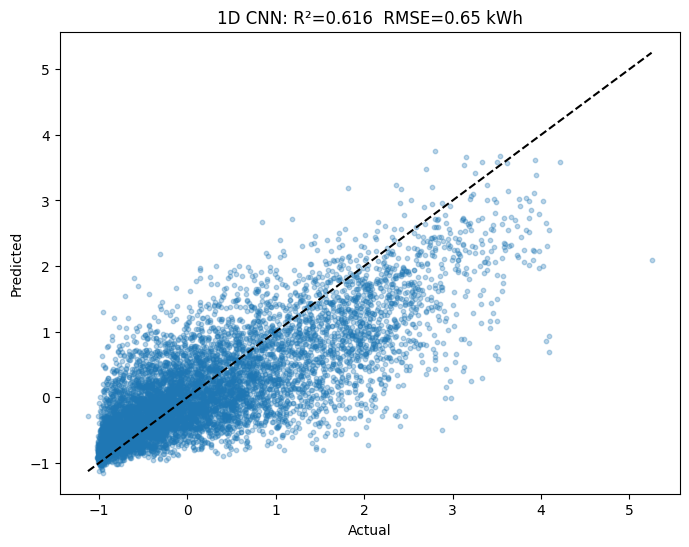

In [23]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).numpy()

from sklearn.metrics import mean_squared_error, r2_score
rmse = np.sqrt(mean_squared_error(y_test, pred_scaled))
r2 = r2_score(y_test, pred_scaled)


plt.figure(figsize=(8, 6))
plt.scatter(y_test, pred_scaled, alpha=0.3, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--')  # perfect prediction line
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'1D CNN: R²={r2:.3f}  RMSE={rmse:.2f} kWh')
plt.show()